# Importing data and libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from palmerpenguins import load_penguins
import numpy as np

In [2]:
data = load_penguins()
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), str(3)
memory usage: 21.6 KB


# Visualizations

## Matplotlib

/tmp/ipykernel_8514/3736519265.py:62: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[2, 1].set_xticklabels(species, rotation=30)


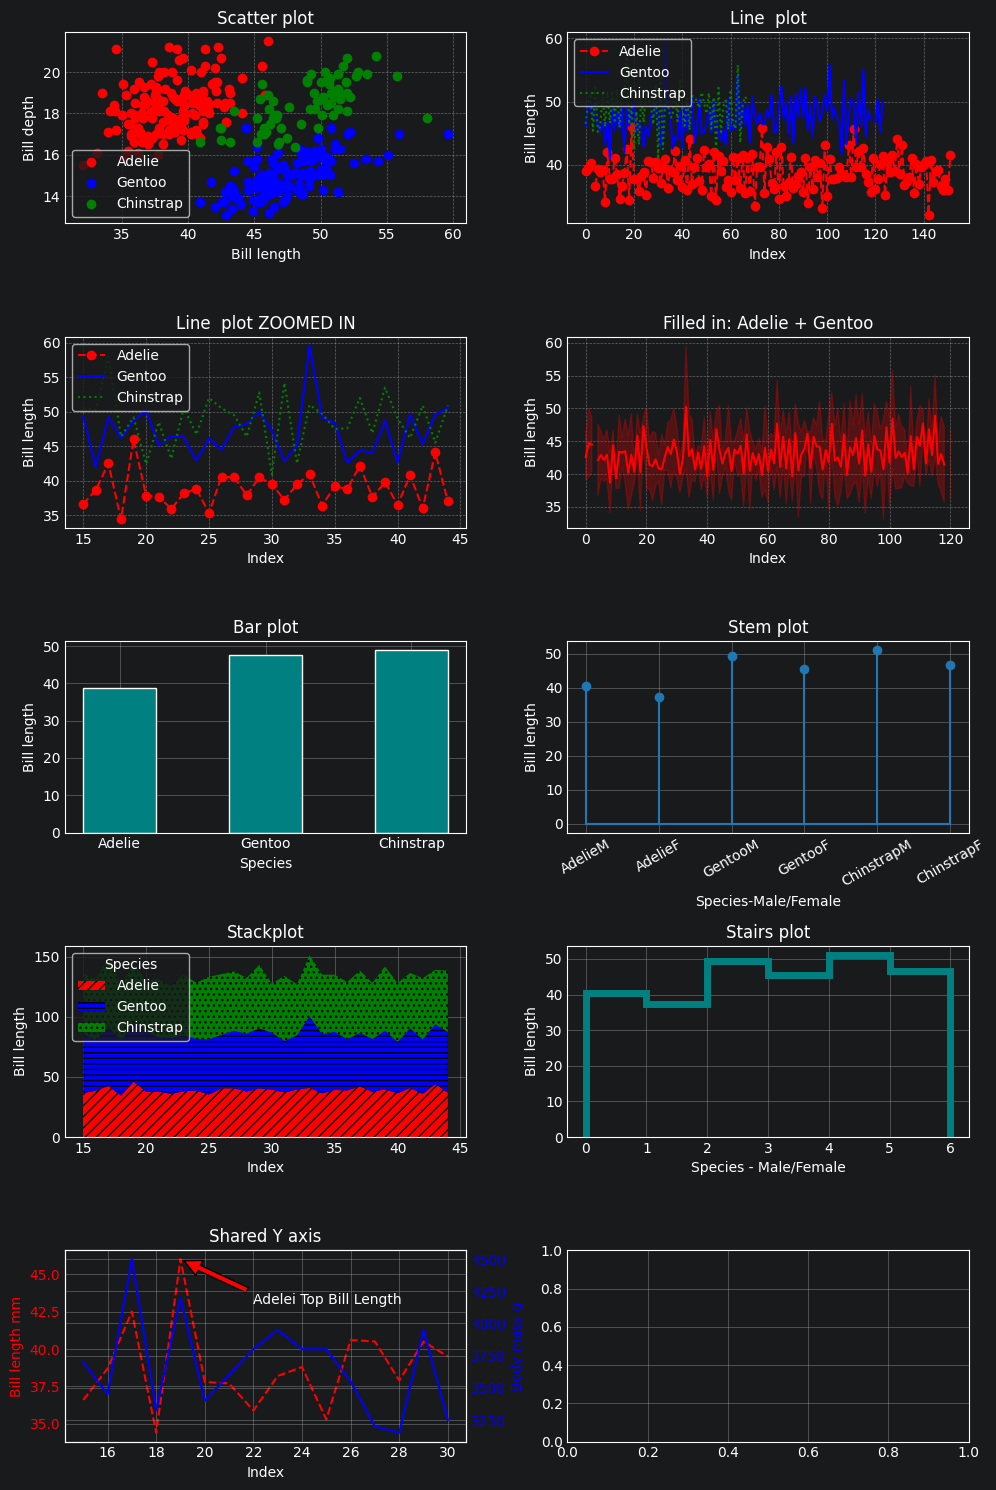

In [109]:
adelei = data[data.species == 'Adelie']
gentoo = data[data.species == 'Gentoo']
chinstrap = data[data.species == 'Chinstrap']

fig, ax = plt.subplots(5, 2, figsize=(10,15))

# Scatter plot
ax[0, 0].scatter(adelei.bill_length_mm, adelei.bill_depth_mm, color='red', label='Adelie')
ax[0, 0].scatter(gentoo.bill_length_mm, gentoo.bill_depth_mm, color='blue', label='Gentoo')
ax[0, 0].scatter(chinstrap.bill_length_mm, chinstrap.bill_depth_mm, color='green', label='Chinstrap')
ax[0, 0].legend(loc='lower left')
ax[0, 0].set_title('Scatter plot')
ax[0, 0].set_xlabel('Bill length')
ax[0, 0].set_ylabel('Bill depth')
ax[0, 0].grid(True, linestyle='--', which='major', axis='both')

# Line plot
ax[0, 1].plot(np.arange(0, adelei.shape[0]), adelei['bill_length_mm'], color='red', label='Adelie', linestyle='--', marker='o')
ax[0, 1].plot(np.arange(0, gentoo.shape[0]), gentoo['bill_length_mm'], color='blue', label='Gentoo', linestyle='-')
ax[0, 1].plot(np.arange(0, chinstrap.shape[0]), chinstrap['bill_length_mm'], color='green', label='Chinstrap', linestyle=':')
ax[0, 1].legend(loc='upper left')
ax[0, 1].set_title('Line  plot')
ax[0, 1].set_xlabel('Index')
ax[0, 1].set_ylabel('Bill length')
ax[0, 1].grid(True, linestyle='--', which='major', axis='both')

# Line plot ZOOMED IN
zoomed_in = np.arange(15, 45)
ax[1,0].plot(zoomed_in, adelei['bill_length_mm'].iloc[15:45], color='red', label='Adelie', linestyle='--', marker='o')
ax[1,0].plot(zoomed_in, gentoo['bill_length_mm'].iloc[15:45], color='blue', label='Gentoo', linestyle='-')
ax[1,0].plot(zoomed_in, chinstrap['bill_length_mm'].iloc[15:45], color='green', label='Chinstrap', linestyle=':')
ax[1,0].legend(loc='upper left')
ax[1,0].set_title('Line  plot ZOOMED IN')
ax[1,0].set_xlabel('Index')
ax[1,0].set_ylabel('Bill length')
ax[1,0].grid(True, linestyle='--', which='major', axis='both')

# Filled in
between = np.arange(0, 121)
adelei_120 = adelei['bill_length_mm'].iloc[0:121]
gentoo_120 = gentoo['bill_length_mm'].iloc[0:121]
ax[1, 1].fill_between(between, adelei_120, gentoo_120, color='red', alpha=0.25)
ax[1, 1].plot(between, (adelei_120.values + gentoo_120.values)/2, color='red', linestyle='-')
ax[1, 1].set_title('Filled in: Adelie + Gentoo')
ax[1, 1].set_xlabel('Index')
ax[1, 1].set_ylabel('Bill length')
ax[1, 1].grid(True, linestyle='--', which='major', axis='both')

# Bar plot (X vs. Height)
species = ['Adelie', 'Gentoo', 'Chinstrap']
bill_length = [adelei.bill_length_mm.mean(), gentoo.bill_length_mm.mean(), chinstrap.bill_length_mm.mean()]
ax[2, 0].bar(species, bill_length, color='teal', edgecolor='white', width=0.5)
ax[2, 0].set_title('Bar plot')
ax[2, 0].set_xlabel('Species')
ax[2, 0].set_ylabel('Bill length')

# Stem plot (useful when there are too many categorical variables)
species = ['AdelieM', 'AdelieF', 'GentooM', 'GentooF', 'ChinstrapM', 'ChinstrapF']
bill_length_sex = [adelei.query('sex == "male"').bill_length_mm.mean(), adelei.query('sex == "female"').bill_length_mm.mean(), gentoo.query('sex == "male"').bill_length_mm.mean(), gentoo.query('sex == "female"').bill_length_mm.mean(), chinstrap.query('sex == "male"').bill_length_mm.mean(), chinstrap.query('sex == "female"').bill_length_mm.mean()]
ax[2, 1].stem(species, bill_length_sex)
ax[2, 1].set_title('Stem plot')
ax[2, 1].set_xticklabels(species, rotation=30)
ax[2, 1].set_xlabel('Species-Male/Female')
ax[2, 1].set_ylabel('Bill length')

# Stackplot
bill_zoom_matrix = np.vstack([adelei['bill_length_mm'].iloc[15:45], gentoo['bill_length_mm'].iloc[15:45], chinstrap['bill_length_mm'].iloc[15:45]])
ax[3, 0].stackplot(zoomed_in, bill_zoom_matrix, labels=['Adelie', 'Gentoo', 'Chinstrap'], baseline='zero', colors=['red', 'blue', 'green'], hatch=['///', '---', '...'])
ax[3, 0].set_title('Stackplot')
ax[3, 0].set_xlabel('Index')
ax[3, 0].set_ylabel('Bill length')
ax[3, 0].legend(loc='upper left', title='Species')

# Stairs
ax[3, 1].stairs(bill_length_sex, linewidth=5, fill=False, color='teal', orientation='vertical')
ax[3, 1].set_title('Stairs plot')
ax[3, 1].set_xlabel('Species - Male/Female')
ax[3, 1].set_ylabel('Bill length')

# Shared Y axis
zoomed_in = np.arange(15, 31)
ax[4, 0].plot(zoomed_in, adelei['bill_length_mm'].iloc[15:31], color='red', linestyle='--')
ax[4, 0].set_title('Shared Y axis')
ax[4, 0].set_xlabel('Index')
ax[4, 0].set_ylabel('Bill length mm', color='red')
ax[4, 0].tick_params(axis='y', labelcolor='red')
ax[4, 0].annotate('Adelei Top Bill Length', xy=(19, 46), xytext=(22, 43), arrowprops=dict(facecolor='red', shrink=0.05))

ax2 = ax[4, 0].twinx()
ax2.plot(zoomed_in, adelei['body_mass_g'].iloc[15:31], color='blue', linestyle='-')
ax2.set_ylabel('Body mass g', color='blue')
ax2.tick_params(axis='y', labelcolor='blue')


plt.tight_layout()
plt.show()

## Seaborn

### Lineplot

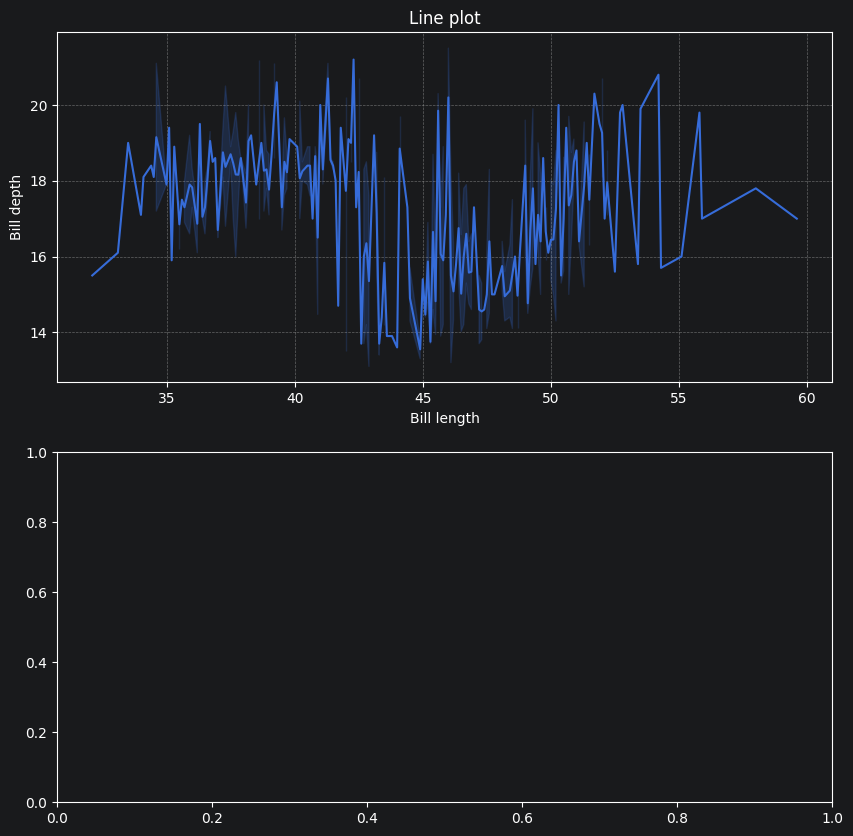

In [4]:
fig, axes = plt.subplots(2,1, figsize=(10,10))

sns.lineplot(data=data, x="bill_length_mm", y="bill_depth_mm", ax=axes[0])
axes[0].set_title('Line plot')
axes[0].set_xlabel('Bill length')
axes[0].set_ylabel('Bill depth')
axes[0].grid(True, linestyle='--', which='major', axis='both')

plt.show()

# DRAFT

In [51]:
bill_length

[np.float64(40.39041095890411),
 np.float64(37.25753424657535),
 np.float64(49.47377049180328),
 np.float64(45.563793103448276),
 np.float64(51.09411764705882),
 np.float64(46.57352941176471)]

In [28]:
np.vstack([adelei['bill_length_mm'].iloc[15:45], gentoo['bill_length_mm'].iloc[15:45]])

array([[36.6, 38.7, 42.5, 34.4, 46. , 37.8, 37.7, 35.9, 38.2, 38.8, 35.3,
        40.6, 40.5, 37.9, 40.5, 39.5, 37.2, 39.5, 40.9, 36.4, 39.2, 38.8,
        42.2, 37.6, 39.8, 36.5, 40.8, 36. , 44.1, 37. ],
       [49.3, 42. , 49.2, 46.2, 48.7, 50.2, 45.1, 46.5, 46.3, 42.9, 46.1,
        44.5, 47.8, 48.2, 50. , 47.3, 42.8, 45.1, 59.6, 49.1, 48.4, 42.6,
        44.4, 44. , 48.7, 42.7, 49.6, 45.3, 49.6, 50.5]])

In [19]:
adelei.query('sex == "male"')

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,male,2007
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,male,2007
13,Adelie,Torgersen,38.6,21.2,191.0,3800.0,male,2007
14,Adelie,Torgersen,34.6,21.1,198.0,4400.0,male,2007
...,...,...,...,...,...,...,...,...
143,Adelie,Dream,40.7,17.0,190.0,3725.0,male,2009
145,Adelie,Dream,39.0,18.7,185.0,3650.0,male,2009
146,Adelie,Dream,39.2,18.6,190.0,4250.0,male,2009
149,Adelie,Dream,37.8,18.1,193.0,3750.0,male,2009


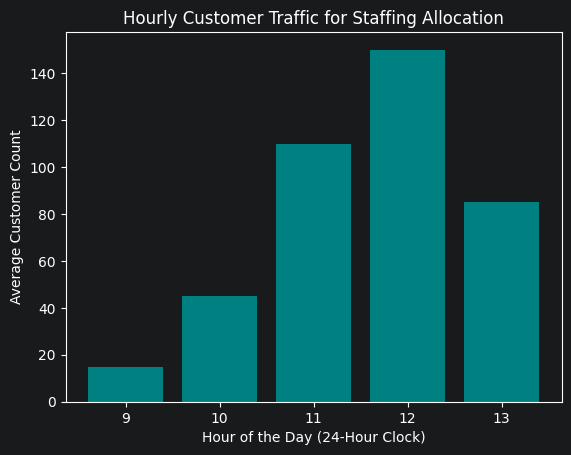

In [5]:
import matplotlib.pyplot as plt

# X: True numerical vector (Continuous hours of operation)
hours_of_day = [9, 10, 11, 12, 13]

# Y: True numerical vector (Average hourly foot traffic)
avg_customers = [15, 45, 110, 150, 85]

# Plotting the bars
plt.bar(hours_of_day, avg_customers, color='teal', width=0.8)

# Labeling the continuous numerical data
plt.xlabel('Hour of the Day (24-Hour Clock)')
plt.ylabel('Average Customer Count')
plt.title('Hourly Customer Traffic for Staffing Allocation')

# Ste

plt.show()


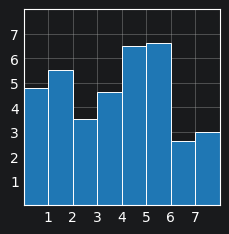

In [7]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('_mpl-gallery')

# make data:
x = 0.5 + np.arange(8)
y = [4.8, 5.5, 3.5, 4.6, 6.5, 6.6, 2.6, 3.0]

# plot
fig, ax = plt.subplots()

ax.bar(x, y, width=1, edgecolor="white", linewidth=0.7)

ax.set(xlim=(0, 8), xticks=np.arange(1, 8),
       ylim=(0, 8), yticks=np.arange(1, 8))

plt.show()

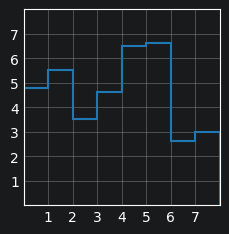

In [8]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('_mpl-gallery')

# make data
y = [4.8, 5.5, 3.5, 4.6, 6.5, 6.6, 2.6, 3.0]

# plot
fig, ax = plt.subplots()

ax.stairs(y, linewidth=1.5)

ax.set(xlim=(0, 8), xticks=np.arange(1, 8),
       ylim=(0, 8), yticks=np.arange(1, 8))

plt.show()

In [9]:
adelei_120 = adelei['bill_length_mm'].iloc[0:121].ffill()
gentoo_120 = gentoo['bill_length_mm'].iloc[0:121].ffill()
print(adelei_120)
print(gentoo_120)

0      39.1
1      39.5
2      40.3
3      40.3
4      36.7
       ... 
116    38.6
117    37.3
118    35.7
119    41.1
120    36.2
Name: bill_length_mm, Length: 121, dtype: float64
152    46.1
153    50.0
154    48.7
155    50.0
156    47.6
       ... 
268    44.5
269    48.8
270    47.2
271    47.2
272    46.8
Name: bill_length_mm, Length: 121, dtype: float64


In [10]:
example = adelei_120.values + gentoo_120.values

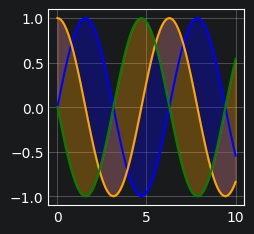

In [11]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)
y3 = -np.sin(x)

fig, ax = plt.subplots()

# 1. Fill between y1 and y2
ax.fill_between(x, y1, y2, color='blue', alpha=0.3)

# 2. Fill between y2 and y3
ax.fill_between(x, y2, y3, color='orange', alpha=0.3)

# Add lines for context
ax.plot(x, y1, color='blue')
ax.plot(x, y2, color='orange')
ax.plot(x, y3, color='green')

plt.show()


In [12]:
data.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,year
count,342.000000,342.000000,342.000000,342.000000,344.000000
mean,43.921930,17.151170,200.915205,4201.754386,2008.029070
std,5.459584,1.974793,14.061714,801.954536,0.818356
min,32.100000,13.100000,172.000000,2700.000000,2007.000000
25%,39.225000,15.600000,190.000000,3550.000000,2007.000000
50%,44.450000,17.300000,197.000000,4050.000000,2008.000000
75%,48.500000,18.700000,213.000000,4750.000000,2009.000000
max,59.600000,21.500000,231.000000,6300.000000,2009.000000
